# Heat Treatment Parameter Prediction

This notebook predicts **heat treatment parameters** (Holding Temperature, Holding Time) from chemical composition and CNN image features using the SEM Microstructure Heat Treatment Prediction pipeline.

**Dataset**: `metadata_latest.csv` (88 usable alloy samples, multi-cycle heat treatment data)

**Targets**: Cycle 1 HoldingTemp + HoldingTime (primary), with Cycle 2 extension

**Approach**: Multi-output ensemble regression (RF, GBR, AdaBoost)

**Sections**:
1. **Data Loading & Exploration** - Load dataset, analyze target availability across cycles
2. **Target Extraction** - Define targets, handle missing data, prevent leakage
3. **Tabular Feature Preprocessing** - Chemical composition features
4. **Image Feature Extraction** - Simulated CNN backbone features
5. **Model Training & Evaluation** - Multi-output ensemble models
6. **Visualization** - Per-target predictions and residual analysis
7. **Extension** - Cycle 2 multi-output prediction

In [1]:
# Standard imports
import os
import re
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Add parent directory to path for local imports
sys.path.insert(0, os.path.abspath('..'))

# Project imports
from src.preprocessing import FeaturePreprocessor
from src.preprocessing.pipeline import PreprocessingConfig, MissingDataConfig, ScalingConfig, EncodingConfig
from src.extraction import FeatureExtractor, BackboneRegistry
from src.extraction.extractor import ExtractionConfig
from src.model_trainer import (
    ModelTrainer, 
    build_ensemble_models, 
    evaluate_model,
    plot_predictions,
    plot_learning_curves,
    plot_model_comparison
)
from src.config import Config
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Display settings
pd.set_option('display.max_columns', 50)
plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

## 1. Data Loading & Exploration

The `metadata_latest.csv` dataset contains 88 usable alloy samples with:
- **Chemical Composition**: C, Mn, Si, Cr, P, S, Mo, Cu, Ni, Al, Nb, V, Ti, Fe
- **Heat Treatment Parameters**: Up to 4 cycles, each with HoldingTemp, HoldingTime, CRate
- **Metadata**: Alloy names, sample IDs, image references

The CSV has a category header row, so we load with `header=1` and filter out empty padding rows.

In [2]:
# Load the metadata dataset
df_raw = pd.read_csv('../datasets/metadata_latest.csv', header=1)  # Skip the category header row
print(f"Raw dataset shape: {df_raw.shape}")

# Filter to rows with actual data (non-null chemical composition)
df = df_raw[df_raw['C (wt.%)'].notna()].copy().reset_index(drop=True)
print(f"Usable samples: {df.shape[0]} (filtered from {len(df_raw)} raw rows)")
print(f"Columns: {len(df.columns)}")
df.head()

Raw dataset shape: (666, 69)
Usable samples: 88 (filtered from 666 raw rows)
Columns: 69


,Alloy,Article url,ID,Original_Image,AI_Cleaned_Image,Augumented_Data,C (wt.%),Mn (wt.%),Si,Cr (wt.%),P,S,Mo,Cu,Ni,Al,Nb,V,Ti,Ti+Nb+V,B,Ce+La,Fe,Pixel_Size,Heat treatment type,...,Cycle2_Rtemp (C),Cycle2_ RPercentage,Cycle2_ Qtype,Cycle2_Qtemp (C),Cycle2_Qtime (min),Cycle3_HRate (C/min),Cycle3_HoldingTemp (°C),Cycle3_HoldingTime (min),Cycle3_CRate (°C/s),Cycle3_rolling,Cycle3_Rtemp,Cycle3_ RPercentage,Cycle3_ Qtype,Cycle3_Qtemp,Cycle3_Qtime,Cycle4_HRate (C/min),Cycle4_HoldingTemp (°C),Cycle4_HoldingTime (min),Cycle4_CRate (°C/s),Cycle4_rolling,Cycle4_Rtemp,Cycle4_ RPercentage,Cycle4_ Qtype,Cycle4_Qtemp,Cycle4_Qtime
0,Spring steel,NaN,3_2_A_Q860-T,NaN,NaN,NaN,0.38,0.44,1.47,1.19,0.0033,0.0045,NaN,NaN,0.57,0.048,0.025,0.11,0.025,NaN,NaN,NaN,95.7342,NaN,Austenitize → Oil quench → Tempering → Water c...,...,NaN,NaN,water,25.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Spring steel,NaN,3_2_B_Q890-T,NaN,NaN,NaN,0.38,0.44,1.47,1.19,0.0033,0.0045,NaN,NaN,0.57,0.048,0.025,0.11,0.025,NaN,NaN,NaN,95.7342,NaN,Austenitize → Oil quench → Tempering → Water c...,...,NaN,NaN,water,25.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Spring steel,NaN,3_2_C_Q920-T,NaN,NaN,NaN,0.38,0.44,1.47,1.19,0.0033,0.0045,NaN,NaN,0.57,0.048,0.025,0.11,0.025,NaN,NaN,NaN,95.7342,NaN,Austenitize → Oil quench → Tempering → Water c...,...,NaN,NaN,water,25.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Spring steel,NaN,3_2_D_Q950-T,NaN,NaN,NaN,0.38,0.44,1.47,1.19,0.0033,0.0045,NaN,NaN,0.57,0.048,0.025,0.11,0.025,NaN,NaN,NaN,95.7342,NaN,Austenitize → Oil quench → Tempering → Water c...,...,NaN,NaN,water,25.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Spring steel,NaN,3_3_A_Q-T300,NaN,NaN,NaN,0.38,0.44,1.47,1.19,0.0033,0.0045,NaN,NaN,0.57,0.048,0.025,0.11,0.025,NaN,NaN,NaN,95.7342,NaN,Austenitize → Oil quench → Tempering → Water c...,...,NaN,NaN,water,25.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
# Display all column names
print("=" * 60)
print("DATASET COLUMNS")
print("=" * 60)

for i, col in enumerate(df.columns):
    print(f"{i:3d}. {col}")

# Identify target-related columns and their availability
print("\n" + "=" * 60)
print("TARGET COLUMN AVAILABILITY (HoldingTemp, HoldingTime, CRate)")
print("=" * 60)

for col in df.columns:
    norm = re.sub(r'\s+', ' ', col).strip()
    if any(kw in norm for kw in ['HoldingTemp', 'HoldingTime', 'CRate']):
        nn = df[col].notna().sum()
        print(f"  {repr(col):55s}  {nn:3d}/{len(df)} ({nn/len(df)*100:.0f}%)")

DATASET COLUMNS
  0. Alloy
  1. Article url
  2. ID
  3. Original_Image
  4. AI_Cleaned_Image
  5. Augumented_Data
  6. C (wt.%)
  7. Mn (wt.%)
  8. Si
  9. Cr (wt.%)
 10. P
 11. S
 12. Mo
 13. Cu
 14. Ni
 15. Al
 16. Nb
 17. V
 18. Ti
 19. Ti+Nb+V
 20. B
 21. Ce+La
 22. Fe
 23. Pixel_Size
 24. Heat treatment type
 25. Num_Cycles
 26. Cycle0_Rolling
 27. Cycle0_Rtemp
 28. Cycle0_ RPercentage
 29. Cycle1_HRate (C/min)
 30. Cycle1_HoldingTemp (C)
 31. Cycle1_HoldingTime (min)
 32. Cycle1_CRate (°C/s)
 33. Cycle1_Rolling
 34. Cycle1_Rtemp
 35. Cycle1_ RPercentage
 36. Cycle1_   Qtype
 37. Cycle1_Qtemp
 38. Cycle1_Qtime(min)
 39. Cycle2_HRate (C/min)
 40. Cycle2_HoldingTemp (C)
 41. Cycle2_HoldingTime (min)
 42. Cycle2_CRate (C/s)
 43. Cycle2_  rolling
 44. Cycle2_Rtemp (C)
 45. Cycle2_ RPercentage
 46. Cycle2_  Qtype
 47. Cycle2_Qtemp  (C)
 48. Cycle2_Qtime   (min)
 49. Cycle3_HRate (C/min)
 50. Cycle3_HoldingTemp   (°C)
 51. Cycle3_HoldingTime     (min)
 52. Cycle3_CRate   (°C/s)
 53. Cy

In [4]:
# Examine data types and missing values
print("Data Types and Missing Values:")
print("-" * 60)

info_df = pd.DataFrame({
    'dtype': df.dtypes,
    'non_null': df.count(),
    'null_count': df.isna().sum(),
    'null_pct': (df.isna().sum() / len(df) * 100).round(1)
})

# Show columns with significant data
info_df[info_df['non_null'] > 0].head(30)

Data Types and Missing Values:
------------------------------------------------------------


,dtype,non_null,null_count,null_pct
Alloy,object,88,0,0.0
ID,object,82,6,6.8
Augumented_Data,object,44,44,50.0
C (wt.%),float64,88,0,0.0
Mn (wt.%),float64,88,0,0.0
Si,float64,88,0,0.0
Cr (wt.%),float64,58,30,34.1
P,float64,45,43,48.9
S,float64,33,55,62.5
Mo,float64,38,50,56.8


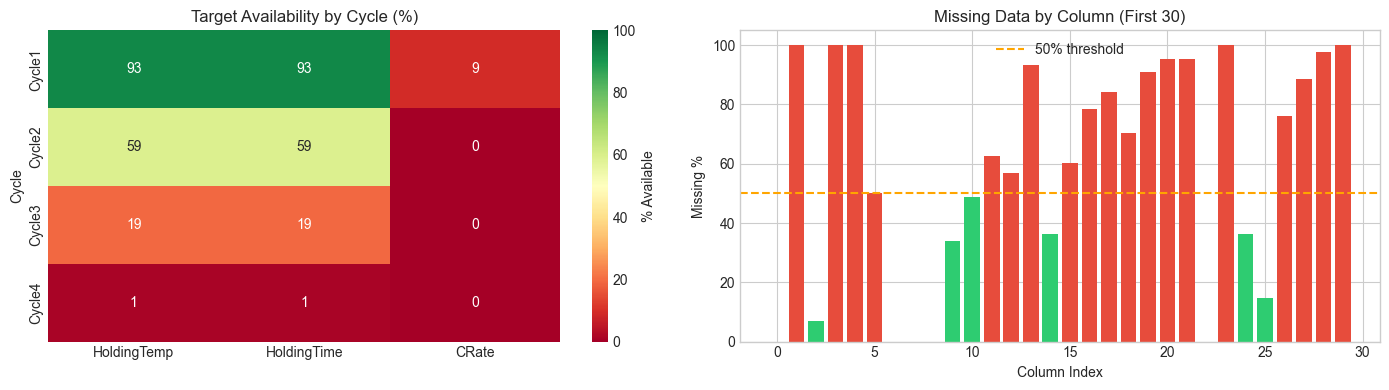


Conclusion:
  - Cycle 1 HoldingTemp & HoldingTime: 93% available -> PRIMARY TARGETS
  - Cycle 2 HoldingTemp & HoldingTime: 59% available -> EXTENSION TARGETS
  - CRate: <10% available across all cycles -> EXCLUDED
  - Cycles 3-4: <20% available -> EXCLUDED


In [5]:
# Target availability heatmap by cycle
target_params = ['HoldingTemp', 'HoldingTime', 'CRate']
cycles = ['Cycle1', 'Cycle2', 'Cycle3', 'Cycle4']

availability = pd.DataFrame(index=cycles, columns=target_params, dtype=float)

for col in df.columns:
    norm = re.sub(r'\s+', ' ', col).strip()
    for cycle in cycles:
        for param in target_params:
            if cycle in norm and param in norm:
                availability.loc[cycle, param] = df[col].notna().sum() / len(df) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Heatmap
sns.heatmap(availability.astype(float), annot=True, fmt='.0f', cmap='RdYlGn',
            vmin=0, vmax=100, ax=axes[0], cbar_kws={'label': '% Available'})
axes[0].set_title('Target Availability by Cycle (%)')
axes[0].set_ylabel('Cycle')

# Missing data bar chart for first 30 columns
missing_pct = (df.iloc[:, :30].isna().sum() / len(df) * 100)
colors = ['#2ecc71' if x < 50 else '#e74c3c' for x in missing_pct]
axes[1].bar(range(len(missing_pct)), missing_pct, color=colors)
axes[1].set_xlabel('Column Index')
axes[1].set_ylabel('Missing %')
axes[1].set_title('Missing Data by Column (First 30)')
axes[1].axhline(y=50, color='orange', linestyle='--', label='50% threshold')
axes[1].legend()

plt.tight_layout()
plt.show()

print("\nConclusion:")
print("  - Cycle 1 HoldingTemp & HoldingTime: 93% available -> PRIMARY TARGETS")
print("  - Cycle 2 HoldingTemp & HoldingTime: 59% available -> EXTENSION TARGETS")
print("  - CRate: <10% available across all cycles -> EXCLUDED")
print("  - Cycles 3-4: <20% available -> EXCLUDED")

Alloy Types in Dataset:
----------------------------------------
Alloy
Commercial-Grade API 5CT Steel     12
DP steel                           12
4340 low-alloy steels              10
34CrNiMo6                           8
Spring steel                        8
AISI 4340                           6
X52 HSLA steel                      6
Ultrafine-grained DP                5
DP-800                              5
RE-microalloyed DP steel            4
440C MSS                            4
DP-LAS                              2
CR54                                1
MS54                                1
CR81                                1
MS81                                1
SS81                                1
MS27                                1
Name: count, dtype: int64


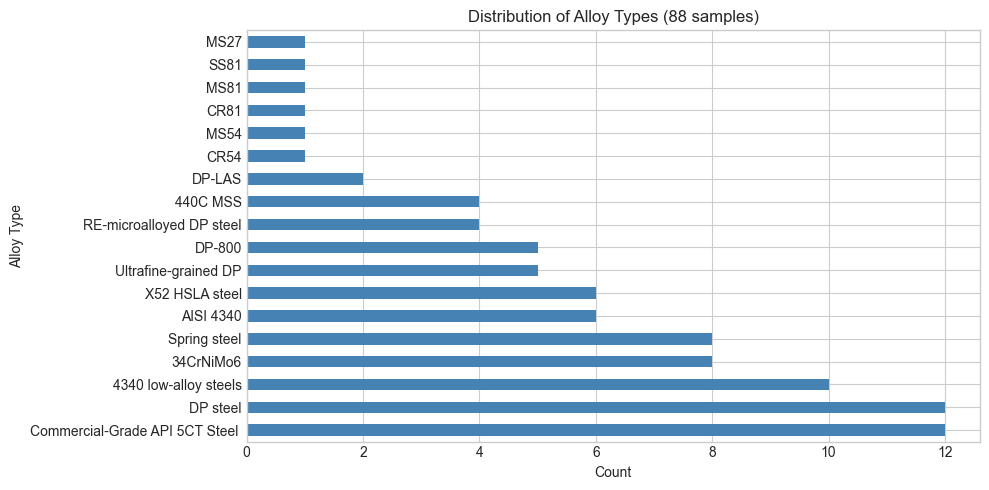

In [6]:
# Examine unique alloy types
print("Alloy Types in Dataset:")
print("-" * 40)
alloy_counts = df['Alloy'].value_counts()
print(alloy_counts)

# Visualize alloy distribution
fig, ax = plt.subplots(figsize=(10, 5))
alloy_counts.plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('Count')
ax.set_ylabel('Alloy Type')
ax.set_title(f'Distribution of Alloy Types ({len(df)} samples)')
plt.tight_layout()
plt.show()

## 2. Target Extraction

**Primary targets**: Cycle 1 HoldingTemp (C) and HoldingTime (min) — 82/88 samples available

**Strategy**:
- CRate excluded due to extreme sparsity (9% for Cycle 1, 0% for Cycles 2-4)
- Cycles 3-4 excluded (<20% availability)
- Samples missing Cycle 1 targets are dropped from training
- All heat treatment columns excluded from input features to prevent target leakage

In [7]:
# Helper to find columns with inconsistent whitespace
def find_column(df, pattern):
    """Find column matching pattern, normalizing whitespace."""
    pattern_norm = re.sub(r'\s+', ' ', pattern).strip()
    for col in df.columns:
        if re.sub(r'\s+', ' ', col).strip() == pattern_norm:
            return col
    return None

# Map target columns across all cycles
TARGET_PATTERNS = {
    'Cycle1_HoldingTemp': 'Cycle1_HoldingTemp (C)',
    'Cycle1_HoldingTime': 'Cycle1_HoldingTime (min)',
    'Cycle2_HoldingTemp': 'Cycle2_HoldingTemp (C)',
    'Cycle2_HoldingTime': 'Cycle2_HoldingTime (min)',
}

target_col_map = {}
print("Target column mapping:")
for key, pattern in TARGET_PATTERNS.items():
    actual = find_column(df, pattern)
    if actual:
        target_col_map[key] = actual
        nn = df[actual].notna().sum()
        print(f"  {key:25s} -> {repr(actual):40s}  ({nn}/{len(df)} available)")
    else:
        print(f"  {key:25s} -> NOT FOUND")

# Extract Cycle 1 primary targets
c1_temp_col = target_col_map['Cycle1_HoldingTemp']
c1_time_col = target_col_map['Cycle1_HoldingTime']

# Filter to samples with both Cycle 1 targets non-null
c1_mask = df[c1_temp_col].notna() & df[c1_time_col].notna()
df_c1 = df[c1_mask].copy().reset_index(drop=True)

target_columns = ['Cycle1_HoldingTemp', 'Cycle1_HoldingTime']
Y_c1 = df_c1[[c1_temp_col, c1_time_col]].values.astype(np.float64)

print(f"\nCycle 1 subset: {len(df_c1)} samples (dropped {len(df) - len(df_c1)} with missing targets)")
print(f"Target matrix shape: {Y_c1.shape}")
print(f"\nTarget statistics:")
for i, name in enumerate(target_columns):
    vals = Y_c1[:, i]
    print(f"  {name}: range=[{vals.min():.1f}, {vals.max():.1f}], mean={vals.mean():.1f}, std={vals.std():.1f}")

# Identify all heat treatment columns to exclude from inputs
ht_cols = [col for col in df.columns if any(kw in col for kw in ['Cycle', 'Heat treatment', 'Num_Cycles'])]
print(f"\nHeat treatment columns to exclude from inputs: {len(ht_cols)}")

Target column mapping:
  Cycle1_HoldingTemp        -> 'Cycle1_HoldingTemp (C)'                  (82/88 available)
  Cycle1_HoldingTime        -> 'Cycle1_HoldingTime (min)'                (82/88 available)
  Cycle2_HoldingTemp        -> 'Cycle2_HoldingTemp (C)'                  (52/88 available)
  Cycle2_HoldingTime        -> 'Cycle2_HoldingTime (min)'                (52/88 available)

Cycle 1 subset: 82 samples (dropped 6 with missing targets)
Target matrix shape: (82, 2)

Target statistics:
  Cycle1_HoldingTemp: range=[730.0, 1200.0], mean=868.9, std=81.9
  Cycle1_HoldingTime: range=[2.0, 120.0], mean=40.0, std=30.9

Heat treatment columns to exclude from inputs: 45


## 3. Tabular Feature Preprocessing

Input features are **chemical composition only** — all heat treatment parameters are excluded to prevent target leakage. In `metadata_latest.csv`, all chemical columns are `float64` (no text-in-numeric issues).

In [8]:
# Select ONLY chemical composition columns as input features
# IMPORTANT: All Cycle*/Heat treatment/Num_Cycles columns excluded to prevent target leakage
chemical_columns = [
    'C (wt.%)', 'Mn (wt.%)', 'Si', 'Cr (wt.%)', 'P', 'S',
    'Mo', 'Cu', 'Ni', 'Al', 'Nb', 'V', 'Ti', 'Fe'
]

# Filter to columns that exist in the Cycle 1 subset
feature_columns = [c for c in chemical_columns if c in df_c1.columns]
print(f"Selected {len(feature_columns)} chemical composition input features:")
for col in feature_columns:
    nn = df_c1[col].notna().sum()
    print(f"  - {col:15s}  {nn:3d}/{len(df_c1)} ({nn/len(df_c1)*100:.0f}%) non-null  dtype={df_c1[col].dtype}")

Selected 14 chemical composition input features:
  - C (wt.%)          82/82 (100%) non-null  dtype=float64
  - Mn (wt.%)         82/82 (100%) non-null  dtype=float64
  - Si                82/82 (100%) non-null  dtype=float64
  - Cr (wt.%)         58/82 (71%) non-null  dtype=float64
  - P                 45/82 (55%) non-null  dtype=float64
  - S                 33/82 (40%) non-null  dtype=float64
  - Mo                38/82 (46%) non-null  dtype=float64
  - Cu                 6/82 (7%) non-null  dtype=float64
  - Ni                56/82 (68%) non-null  dtype=float64
  - Al                35/82 (43%) non-null  dtype=float64
  - Nb                13/82 (16%) non-null  dtype=float64
  - V                  8/82 (10%) non-null  dtype=float64
  - Ti                20/82 (24%) non-null  dtype=float64
  - Fe                82/82 (100%) non-null  dtype=float64


In [9]:
# Create preprocessing configuration
preproc_config = PreprocessingConfig(
    missing_data=MissingDataConfig(
        column_drop_threshold=0.95,  # Drop columns with >95% missing
        row_fill_threshold=0.50,     # Raised to handle moderate missingness (P=55%, S=40%)
        numeric_fill_strategy='median',  # Robust for composition data
        categorical_fill_strategy='mode'
    ),
    scaling=ScalingConfig(
        method='standard',
        enabled=True
    ),
    encoding=EncodingConfig(
        categorical='onehot',
        max_categories=50
    )
)

print("Preprocessing Configuration:")
print(f"  Column drop threshold: {preproc_config.missing_data.column_drop_threshold}")
print(f"  Row fill threshold: {preproc_config.missing_data.row_fill_threshold}")
print(f"  Numeric fill strategy: {preproc_config.missing_data.numeric_fill_strategy}")
print(f"  Scaling method: {preproc_config.scaling.method}")

Preprocessing Configuration:
  Column drop threshold: 0.95
  Row fill threshold: 0.5
  Numeric fill strategy: median
  Scaling method: standard


In [10]:
# Initialize and fit the preprocessor on the Cycle 1 subset
preprocessor = FeaturePreprocessor(preproc_config)

df_features = df_c1[feature_columns].copy()

print("Fitting preprocessor...")
print("=" * 60)
X_tabular = preprocessor.fit_transform(df_features)

print(f"\nPreprocessed feature shape: {X_tabular.shape}")
print(f"\nFeature names ({len(preprocessor.get_feature_names())}):")
for name in preprocessor.get_feature_names():
    print(f"  - {name}")

if preprocessor.get_dropped_columns():
    print(f"\nDropped columns: {preprocessor.get_dropped_columns()}")

Fitting preprocessor...
  C (wt.%): float64 → numeric
  Mn (wt.%): float64 → numeric
  Si: float64 → numeric
  Cr (wt.%): float64 → numeric
  P: float64 → numeric
  S: float64 → numeric
  Mo: float64 → numeric
  Cu: float64 → numeric
  Ni: float64 → numeric
  Al: float64 → numeric
  Nb: float64 → numeric
  V: float64 → numeric
  Ti: float64 → numeric
  Fe: float64 → numeric
  Fitted 14 columns, dropped 0, output features: 14

Preprocessed feature shape: (82, 14)

Feature names (14):
  - C (wt.%)
  - Mn (wt.%)
  - Si
  - Cr (wt.%)
  - P
  - S
  - Mo
  - Cu
  - Ni
  - Al
  - Nb
  - V
  - Ti
  - Fe


## 4. Image Feature Extraction

The extraction module supports multiple CNN backbones:
- **Classic CNNs**: VGG16, VGG19, ResNet18/50/101
- **Modern Architectures**: DenseNet121, EfficientNet-B0/B4, ConvNeXt-Tiny
- **Self-supervised**: DINOv2 (ViT-S/B/L)

Image features are simulated below since actual SEM images are not yet available.

In [11]:
# List available backbones
print("Available CNN Backbones:")
print("=" * 40)

available = BackboneRegistry.list_available()
for name in sorted(available):
    print(f"  - {name}")

print(f"\nTotal: {len(available)} backbones available")

Available CNN Backbones:
  - convnext_tiny
  - densenet121
  - dinov2_vitb14
  - dinov2_vitl14
  - dinov2_vits14
  - efficientnet_b0
  - efficientnet_b4
  - mobilenet_v3
  - resnet101
  - resnet18
  - resnet50
  - vgg16
  - vgg19

Total: 13 backbones available


In [12]:
# Demonstrate extraction configuration (without actual images)
extraction_config = ExtractionConfig(
    backbones=['resnet50', 'vgg16'],  # Use multiple backbones
    img_size=224,
    batch_size=16,
    num_workers=2,
    pooling='avg'
)

print("Feature Extraction Configuration:")
print(f"  Backbones: {extraction_config.backbones}")
print(f"  Image size: {extraction_config.img_size}x{extraction_config.img_size}")
print(f"  Batch size: {extraction_config.batch_size}")
print(f"  Pooling: {extraction_config.pooling}")

# Show expected feature dimensions
backbone_dims = {
    'vgg16': 512, 'vgg19': 512,
    'resnet18': 512, 'resnet50': 2048, 'resnet101': 2048,
    'densenet121': 1024,
    'efficientnet_b0': 1280, 'efficientnet_b4': 1792,
    'convnext_tiny': 768,
    'mobilenet_v3': 960,
    'dinov2_vits14': 384, 'dinov2_vitb14': 768, 'dinov2_vitl14': 1024
}

total_dim = sum(backbone_dims.get(b, 0) for b in extraction_config.backbones)
print(f"\nExpected feature dimension: {total_dim}")

Feature Extraction Configuration:
  Backbones: ['resnet50', 'vgg16']
  Image size: 224x224
  Batch size: 16
  Pooling: avg

Expected feature dimension: 2560


In [13]:
# Simulate image features for the Cycle 1 subset (no actual images available yet)
# In real usage: extractor.extract_features(image_paths)

n_samples = len(df_c1)  # 82 samples in the Cycle 1 subset
feature_dim = 2560  # resnet50 (2048) + vgg16 (512)

np.random.seed(42)
X_images = np.random.randn(n_samples, feature_dim).astype(np.float32)

print(f"Simulated image features shape: {X_images.shape}")
print(f"  Samples: {n_samples}")
print(f"  Feature dimension: {feature_dim}")

Simulated image features shape: (82, 2560)
  Samples: 82
  Feature dimension: 2560


## 5. Model Training & Evaluation

Multi-output regression with 2 targets (Cycle 1 HoldingTemp + HoldingTime):
- **Random Forest**: Native multi-output support
- **Gradient Boosting**: Wrapped in MultiOutputRegressor
- **AdaBoost**: Wrapped in MultiOutputRegressor

**Note**: Learning curves (`staged_predict`) are only available for single-output boosting models, so they are skipped for this multi-output task.

In [14]:
# Use REAL heat treatment targets (extracted in Section 2)
Y = Y_c1  # Shape: (82, 2) — HoldingTemp + HoldingTime

print(f"Target shape: {Y.shape}")
print(f"Target columns: {target_columns}")
for i, name in enumerate(target_columns):
    print(f"  {name}: range=[{Y[:, i].min():.1f}, {Y[:, i].max():.1f}], "
          f"mean={Y[:, i].mean():.1f}, std={Y[:, i].std():.1f}")

Target shape: (82, 2)
Target columns: ['Cycle1_HoldingTemp', 'Cycle1_HoldingTime']
  Cycle1_HoldingTemp: range=[730.0, 1200.0], mean=868.9, std=81.9
  Cycle1_HoldingTime: range=[2.0, 120.0], mean=40.0, std=30.9


In [15]:
# Combine image and tabular features
X_combined = np.concatenate([X_images, X_tabular], axis=1)

print(f"Combined feature matrix shape: {X_combined.shape}")
print(f"  Image features: {X_images.shape[1]}")
print(f"  Tabular features: {X_tabular.shape[1]}")
print(f"  Total: {X_combined.shape[1]}")
print(f"  Samples: {X_combined.shape[0]}")
print(f"  Targets: {Y.shape[1]} ({', '.join(target_columns)})")

Combined feature matrix shape: (82, 2574)
  Image features: 2560
  Tabular features: 14
  Total: 2574
  Samples: 82
  Targets: 2 (Cycle1_HoldingTemp, Cycle1_HoldingTime)


In [16]:
# Create a minimal config for the trainer
config = Config(
    random_seed=42,
    model_dir='../models'
)

# Initialize trainer with configurable n_estimators
trainer = ModelTrainer(config, n_estimators=100)  # Reduced for faster demo

print(f"Model Trainer initialized:")
print(f"  Random seed: {config.random_seed}")
print(f"  N estimators: {trainer.n_estimators}")
print(f"  Model directory: {config.model_dir}")

Model Trainer initialized:
  Random seed: 42
  N estimators: 100
  Model directory: ../models


In [17]:
# Split data into train/val/test sets
X_train, X_val, X_test, Y_train, Y_val, Y_test = trainer.split_data(
    X_combined, Y,
    test_size=0.15,
    val_size=0.15
)

print(f"\nData splits:")
print(f"  Train: {X_train.shape}")
print(f"  Val: {X_val.shape}")
print(f"  Test: {X_test.shape}")

Data split: train=58, val=11, test=13

Data splits:
  Train: (58, 2574)
  Val: (11, 2574)
  Test: (13, 2574)


In [18]:
# Train all models and track learning curves
print("\nTraining ensemble models...")
print("=" * 60)

best_model_name = trainer.train_and_evaluate(
    X_train, Y_train,
    X_val, Y_val,
    target_columns,
    track_learning_curves=True  # Enable learning curve tracking
)


Training ensemble models...
Building models for 2 target(s) with 100 estimators...

Training RF...
Validation: R2=0.5962, MAE=19.2368, RMSE=29.2133
  Cycle1_HoldingTemp: R2=0.424, MAE=29.895, RMSE=38.457
  Cycle1_HoldingTime: R2=0.769, MAE=8.578, RMSE=15.095

Training GBR...
Validation: R2=0.6257, MAE=19.9901, RMSE=30.5503
  Cycle1_HoldingTemp: R2=0.286, MAE=37.057, RMSE=42.814
  Cycle1_HoldingTime: R2=0.966, MAE=2.923, RMSE=5.800

Training ABR...
Validation: R2=0.5528, MAE=19.4248, RMSE=33.1094
  Cycle1_HoldingTemp: R2=0.170, MAE=34.319, RMSE=46.140
  Cycle1_HoldingTime: R2=0.936, MAE=4.530, RMSE=7.973

✓ Best model: GBR (R2=0.6257)


In [19]:
# Learning curves are not available for multi-output models (staged_predict requires single output)
# This cell will report "No learning histories" which is expected behavior
print("Learning Curves:")
print("=" * 60)
print("Skipped: staged_predict is not available for multi-output boosting models.")
print("Learning curves are only supported when n_targets == 1.")

Learning Curves:
Skipped: staged_predict is not available for multi-output boosting models.
Learning curves are only supported when n_targets == 1.


In [20]:
# Evaluate all models on test set
test_results = trainer.evaluate_all_on_test(X_test, Y_test, target_columns)


Test Set Evaluation - All Models

RF:
  R2=0.7292, MAE=20.1150, RMSE=30.2273
    Cycle1_HoldingTemp: R2=0.740, MAE=30.299, RMSE=39.623
    Cycle1_HoldingTime: R2=0.718, MAE=9.931, RMSE=16.044

GBR:
  R2=0.7960, MAE=22.0756, RMSE=32.4962
    Cycle1_HoldingTemp: R2=0.661, MAE=38.717, RMSE=45.264
    Cycle1_HoldingTime: R2=0.931, MAE=5.434, RMSE=7.950

ABR:
  R2=0.5995, MAE=28.7359, RMSE=46.1177
    Cycle1_HoldingTemp: R2=0.314, MAE=49.832, RMSE=64.410
    Cycle1_HoldingTime: R2=0.885, MAE=7.640, RMSE=10.249

✓ Best on test: GBR (R2=0.7960)


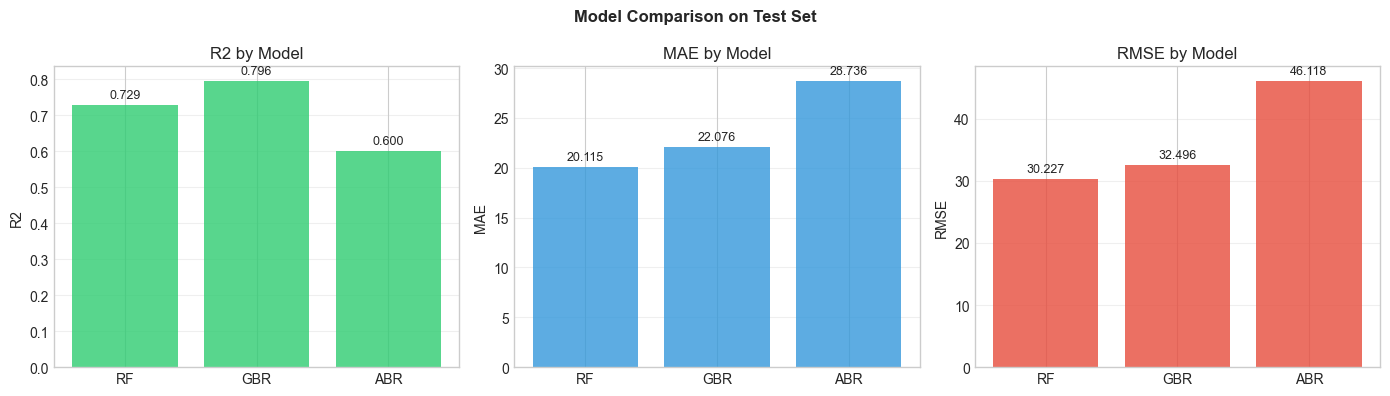

In [21]:
# Plot model comparison
trainer.plot_test_comparison(show=True)

## 6. Predictions Visualization

Per-target predicted vs actual plots and residual analysis for the multi-output model.

In [22]:
# Get predictions from best model
Y_pred = trainer.best_model.predict(X_test)

if Y_pred.ndim == 1:
    Y_pred = Y_pred.reshape(-1, 1)

print(f"Predictions shape: {Y_pred.shape}")
print(f"Best model: {trainer.best_model_name}")

# Per-target metrics
for i, col in enumerate(target_columns):
    r2 = r2_score(Y_test[:, i], Y_pred[:, i])
    mae = mean_absolute_error(Y_test[:, i], Y_pred[:, i])
    rmse = np.sqrt(mean_squared_error(Y_test[:, i], Y_pred[:, i]))
    print(f"  {col}: R2={r2:.4f}, MAE={mae:.2f}, RMSE={rmse:.2f}")

Predictions shape: (13, 2)
Best model: GBR
  Cycle1_HoldingTemp: R2=0.6613, MAE=38.72, RMSE=45.26
  Cycle1_HoldingTime: R2=0.9307, MAE=5.43, RMSE=7.95


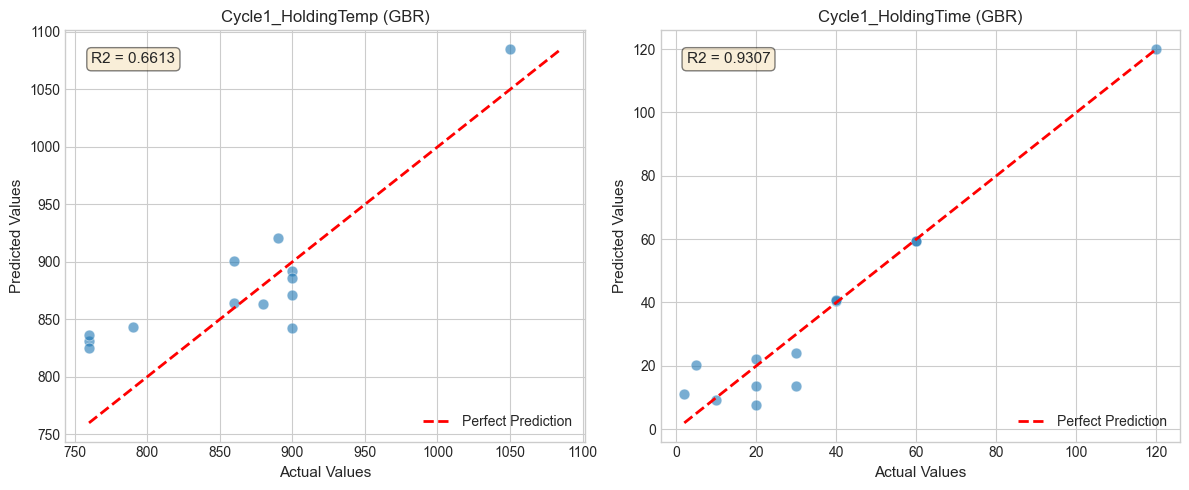

In [23]:
# Predicted vs actual — one subplot per target
fig, axes = plt.subplots(1, len(target_columns), figsize=(6 * len(target_columns), 5))
if len(target_columns) == 1:
    axes = [axes]

for i, (ax, col) in enumerate(zip(axes, target_columns)):
    y_true = Y_test[:, i]
    y_pred = Y_pred[:, i]

    ax.scatter(y_true, y_pred, alpha=0.6, edgecolors='white', linewidth=0.5, s=60)

    mn = min(y_true.min(), y_pred.min())
    mx = max(y_true.max(), y_pred.max())
    ax.plot([mn, mx], [mn, mx], 'r--', linewidth=2, label='Perfect Prediction')

    ax.set_xlabel('Actual Values', fontsize=11)
    ax.set_ylabel('Predicted Values', fontsize=11)
    ax.set_title(f'{col} ({trainer.best_model_name})', fontsize=12)
    ax.legend()

    r2 = r2_score(y_true, y_pred)
    ax.annotate(f'R2 = {r2:.4f}', xy=(0.05, 0.92), xycoords='axes fraction',
                fontsize=11, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

Cycle1_HoldingTemp residual stats: mean=-19.42, std=40.89, min=-76.37, max=57.77
Cycle1_HoldingTime residual stats: mean=1.13, std=7.87, min=-15.41, max=16.48


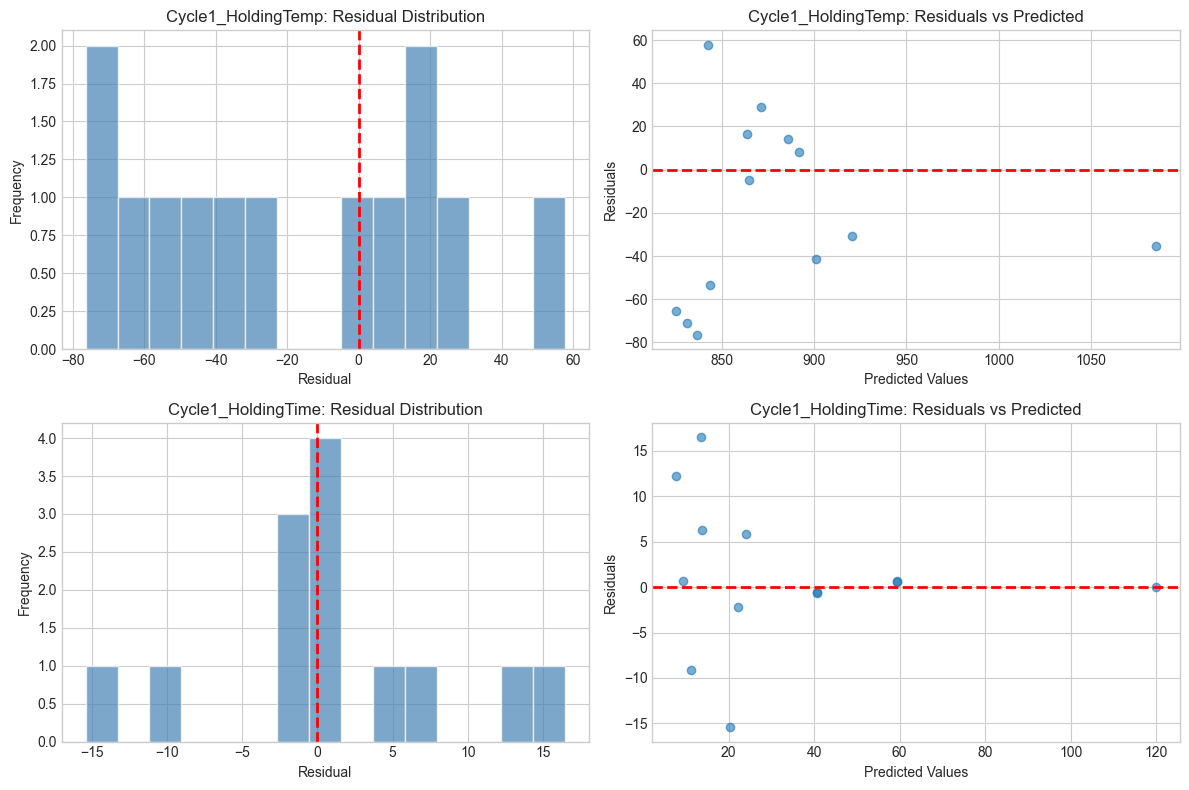

In [24]:
# Residual analysis — per target
n_targets = len(target_columns)
fig, axes = plt.subplots(n_targets, 2, figsize=(12, 4 * n_targets))
if n_targets == 1:
    axes = axes.reshape(1, -1)

for i, col in enumerate(target_columns):
    residuals = Y_test[:, i] - Y_pred[:, i]

    # Residual distribution
    axes[i, 0].hist(residuals, bins=15, color='steelblue', alpha=0.7, edgecolor='white')
    axes[i, 0].axvline(x=0, color='red', linestyle='--', linewidth=2)
    axes[i, 0].set_xlabel('Residual')
    axes[i, 0].set_ylabel('Frequency')
    axes[i, 0].set_title(f'{col}: Residual Distribution')

    # Residuals vs predicted
    axes[i, 1].scatter(Y_pred[:, i], residuals, alpha=0.6)
    axes[i, 1].axhline(y=0, color='red', linestyle='--', linewidth=2)
    axes[i, 1].set_xlabel('Predicted Values')
    axes[i, 1].set_ylabel('Residuals')
    axes[i, 1].set_title(f'{col}: Residuals vs Predicted')

    print(f"{col} residual stats: mean={residuals.mean():.2f}, std={residuals.std():.2f}, "
          f"min={residuals.min():.2f}, max={residuals.max():.2f}")

plt.tight_layout()
plt.show()

In [25]:
# Final summary — Cycle 1 model
print("=" * 60)
print("CYCLE 1 MODEL SUMMARY")
print("=" * 60)
print(f"\nDataset: {n_samples} samples (Cycle 1 subset from metadata_latest.csv)")
print(f"Targets: {target_columns} ({len(target_columns)} outputs)")
print(f"Tabular features: {X_tabular.shape[1]} (chemical composition)")
print(f"Image features: {X_images.shape[1]} (simulated)")
print(f"Total features: {X_combined.shape[1]}")
print(f"\nBest model: {trainer.best_model_name}")
print(f"Test R2 (avg): {test_results[trainer.best_model_name]['R2']:.4f}")
print(f"Test MAE (avg): {test_results[trainer.best_model_name]['MAE']:.4f}")
print(f"Test RMSE (avg): {test_results[trainer.best_model_name]['RMSE']:.4f}")

# Per-target breakdown
print(f"\nPer-target test results ({trainer.best_model_name}):")
for i, col in enumerate(target_columns):
    r2 = r2_score(Y_test[:, i], Y_pred[:, i])
    mae = mean_absolute_error(Y_test[:, i], Y_pred[:, i])
    rmse = np.sqrt(mean_squared_error(Y_test[:, i], Y_pred[:, i]))
    print(f"  {col}: R2={r2:.4f}, MAE={mae:.2f}, RMSE={rmse:.2f}")
print("=" * 60)

CYCLE 1 MODEL SUMMARY

Dataset: 82 samples (Cycle 1 subset from metadata_latest.csv)
Targets: ['Cycle1_HoldingTemp', 'Cycle1_HoldingTime'] (2 outputs)
Tabular features: 14 (chemical composition)
Image features: 2560 (simulated)
Total features: 2574

Best model: GBR
Test R2 (avg): 0.7960
Test MAE (avg): 22.0756
Test RMSE (avg): 32.4962

Per-target test results (GBR):
  Cycle1_HoldingTemp: R2=0.6613, MAE=38.72, RMSE=45.26
  Cycle1_HoldingTime: R2=0.9307, MAE=5.43, RMSE=7.95


## 7. Extension: Cycle 1 + Cycle 2 Multi-Output Prediction

52 samples have both Cycle 1 and Cycle 2 targets available. This section trains a 4-output model:
- Cycle1_HoldingTemp, Cycle1_HoldingTime
- Cycle2_HoldingTemp, Cycle2_HoldingTime

**Tradeoff**: More targets but fewer samples (52 vs 82).

In [26]:
# Filter to samples with all 4 targets (Cycle 1 + Cycle 2) available
c2_temp_col = target_col_map['Cycle2_HoldingTemp']
c2_time_col = target_col_map['Cycle2_HoldingTime']

c1c2_mask = (
    df[c1_temp_col].notna() & df[c1_time_col].notna() &
    df[c2_temp_col].notna() & df[c2_time_col].notna()
)
df_c1c2 = df[c1c2_mask].copy().reset_index(drop=True)

target_columns_ext = [
    'Cycle1_HoldingTemp', 'Cycle1_HoldingTime',
    'Cycle2_HoldingTemp', 'Cycle2_HoldingTime'
]
target_actual_cols = [c1_temp_col, c1_time_col, c2_temp_col, c2_time_col]
Y_c1c2 = df_c1c2[target_actual_cols].values.astype(np.float64)

print(f"Cycle 1+2 subset: {len(df_c1c2)} samples")
print(f"Target matrix shape: {Y_c1c2.shape}")
print(f"\nTarget statistics:")
for i, name in enumerate(target_columns_ext):
    vals = Y_c1c2[:, i]
    print(f"  {name}: range=[{vals.min():.1f}, {vals.max():.1f}], mean={vals.mean():.1f}, std={vals.std():.1f}")

Cycle 1+2 subset: 52 samples
Target matrix shape: (52, 4)

Target statistics:
  Cycle1_HoldingTemp: range=[830.0, 1200.0], mean=899.9, std=70.3
  Cycle1_HoldingTime: range=[20.0, 60.0], mean=45.4, std=16.2
  Cycle2_HoldingTemp: range=[300.0, 900.0], mean=638.3, std=187.2
  Cycle2_HoldingTime: range=[10.0, 120.0], mean=43.5, std=36.2


In [28]:
# Preprocess features for the Cycle 1+2 subset
preprocessor_ext = FeaturePreprocessor(preproc_config)
df_features_ext = df_c1c2[feature_columns].copy()
X_tabular_ext = preprocessor_ext.fit_transform(df_features_ext)

# Simulate image features for this subset
n_ext = len(df_c1c2)
np.random.seed(42)
X_images_ext = np.random.randn(n_ext, feature_dim).astype(np.float32)

# Combine
X_combined_ext = np.concatenate([X_images_ext, X_tabular_ext], axis=1)
print(f"Cycle 1+2 feature matrix: {X_combined_ext.shape}")
print(f"Cycle 1+2 target matrix: {Y_c1c2.shape}")

  C (wt.%): float64 → numeric
  Mn (wt.%): float64 → numeric
  Si: float64 → numeric
  Cr (wt.%): float64 → numeric
  P: float64 → numeric
  S: float64 → numeric
  Mo: float64 → numeric
  Cu: float64 → numeric
  Ni: float64 → numeric
  Al: float64 → numeric
  Nb: float64 → numeric
  V: float64 → numeric
  Ti: float64 → numeric
  Fe: float64 → numeric
  Fitted 14 columns, dropped 0, output features: 14
Cycle 1+2 feature matrix: (52, 2574)
Cycle 1+2 target matrix: (52, 4)


In [29]:
# Train Cycle 1+2 model (4 outputs)
trainer_ext = ModelTrainer(config, n_estimators=100)

X_train_ext, X_val_ext, X_test_ext, Y_train_ext, Y_val_ext, Y_test_ext = trainer_ext.split_data(
    X_combined_ext, Y_c1c2, test_size=0.15, val_size=0.15
)

print(f"Cycle 1+2 splits: train={X_train_ext.shape[0]}, val={X_val_ext.shape[0]}, test={X_test_ext.shape[0]}")

print("\nTraining Cycle 1+2 ensemble models...")
print("=" * 60)
best_ext = trainer_ext.train_and_evaluate(
    X_train_ext, Y_train_ext,
    X_val_ext, Y_val_ext,
    target_columns_ext,
    track_learning_curves=False
)

test_results_ext = trainer_ext.evaluate_all_on_test(X_test_ext, Y_test_ext, target_columns_ext)

Data split: train=37, val=7, test=8
Cycle 1+2 splits: train=37, val=7, test=8

Training Cycle 1+2 ensemble models...
Building models for 4 target(s) with 100 estimators...

Training RF...
Validation: R2=-0.4577, MAE=44.0518, RMSE=59.7045
  Cycle1_HoldingTemp: R2=-2.622, MAE=37.171, RMSE=50.279
  Cycle1_HoldingTime: R2=0.110, MAE=14.771, RMSE=15.831
  Cycle2_HoldingTemp: R2=0.479, MAE=96.357, RMSE=99.746
  Cycle2_HoldingTime: R2=0.203, MAE=27.907, RMSE=39.124

Training GBR...
Validation: R2=0.8699, MAE=11.1403, RMSE=21.0899
  Cycle1_HoldingTemp: R2=0.716, MAE=11.810, RMSE=14.082
  Cycle1_HoldingTime: R2=0.860, MAE=3.313, RMSE=6.289
  Cycle2_HoldingTemp: R2=0.921, MAE=25.213, RMSE=38.852
  Cycle2_HoldingTime: R2=0.983, MAE=4.225, RMSE=5.640

Training ABR...
Validation: R2=0.1362, MAE=35.4232, RMSE=63.9714
  Cycle1_HoldingTemp: R2=-0.661, MAE=27.135, RMSE=34.050
  Cycle1_HoldingTime: R2=0.493, MAE=5.714, RMSE=11.952
  Cycle2_HoldingTemp: R2=0.266, MAE=89.439, RMSE=118.348
  Cycle2_Holding

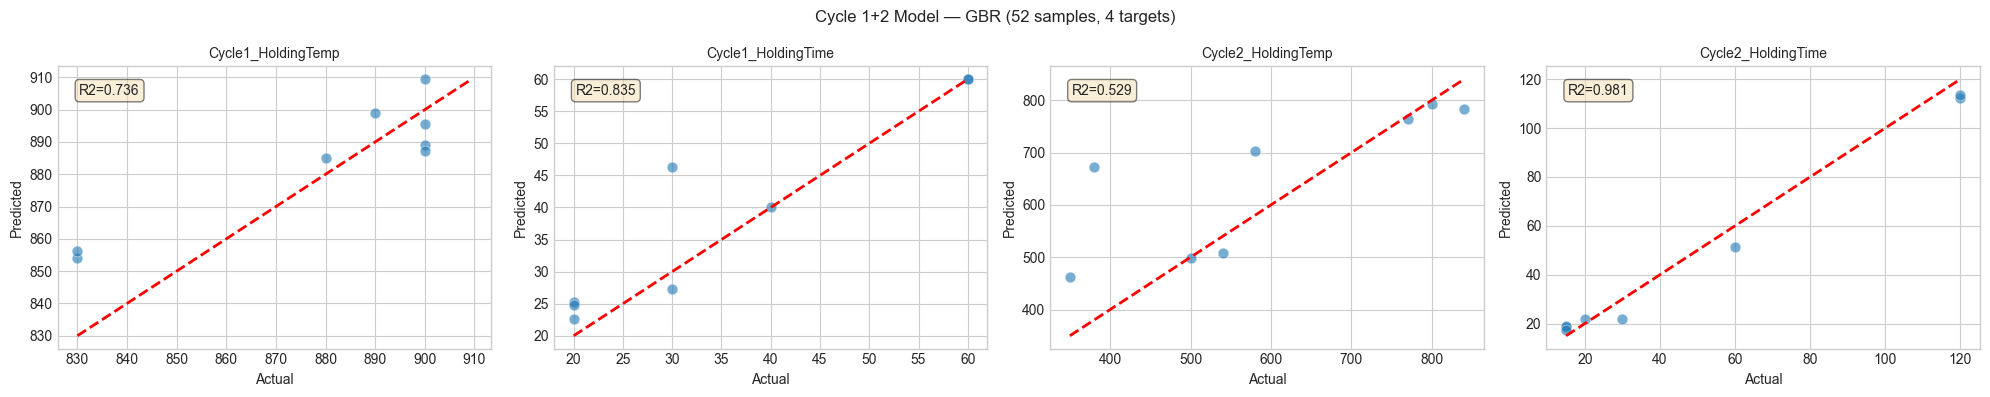

In [30]:
# Predicted vs actual for the 4-output Cycle 1+2 model
Y_pred_ext = trainer_ext.best_model.predict(X_test_ext)
if Y_pred_ext.ndim == 1:
    Y_pred_ext = Y_pred_ext.reshape(-1, 1)

fig, axes = plt.subplots(1, 4, figsize=(20, 4))
for i, (ax, col) in enumerate(zip(axes, target_columns_ext)):
    y_true = Y_test_ext[:, i]
    y_pred = Y_pred_ext[:, i]

    ax.scatter(y_true, y_pred, alpha=0.6, edgecolors='white', linewidth=0.5, s=60)
    mn, mx = min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())
    ax.plot([mn, mx], [mn, mx], 'r--', linewidth=2)
    ax.set_xlabel('Actual', fontsize=10)
    ax.set_ylabel('Predicted', fontsize=10)
    ax.set_title(col, fontsize=10)

    r2 = r2_score(y_true, y_pred)
    ax.annotate(f'R2={r2:.3f}', xy=(0.05, 0.90), xycoords='axes fraction',
                fontsize=10, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.suptitle(f'Cycle 1+2 Model — {trainer_ext.best_model_name} ({n_ext} samples, 4 targets)', fontsize=12)
plt.tight_layout()
plt.show()

In [31]:
# Comparison: Cycle 1 only vs Cycle 1+2
print("=" * 60)
print("MODEL COMPARISON: Cycle 1 vs Cycle 1+2")
print("=" * 60)

print(f"\n{'':30s} {'Cycle 1 Only':>15s} {'Cycle 1+2':>15s}")
print(f"{'':30s} {'(82 samples)':>15s} {'(52 samples)':>15s}")
print("-" * 60)
print(f"{'Targets':30s} {'2':>15s} {'4':>15s}")
print(f"{'Best model':30s} {trainer.best_model_name:>15s} {trainer_ext.best_model_name:>15s}")
print(f"{'Test R2 (avg)':30s} {test_results[trainer.best_model_name]['R2']:>15.4f} {test_results_ext[trainer_ext.best_model_name]['R2']:>15.4f}")
print(f"{'Test MAE (avg)':30s} {test_results[trainer.best_model_name]['MAE']:>15.2f} {test_results_ext[trainer_ext.best_model_name]['MAE']:>15.2f}")
print(f"{'Test RMSE (avg)':30s} {test_results[trainer.best_model_name]['RMSE']:>15.2f} {test_results_ext[trainer_ext.best_model_name]['RMSE']:>15.2f}")
print("=" * 60)
print("\nNote: Image features are simulated (random). Real CNN features from SEM")
print("images should improve predictions significantly.")

MODEL COMPARISON: Cycle 1 vs Cycle 1+2

                                  Cycle 1 Only       Cycle 1+2
                                  (82 samples)    (52 samples)
------------------------------------------------------------
Targets                                      2               4
Best model                                 GBR             GBR
Test R2 (avg)                           0.7960          0.7704
Test MAE (avg)                           22.08           25.31
Test RMSE (avg)                          32.50           61.39

Note: Image features are simulated (random). Real CNN features from SEM
images should improve predictions significantly.
